In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer_old
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NC.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/AIBL/NC/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/AIBL/AD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('MCI.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/AIBL/MCI/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #44
print(count_no) #247
print(count_mci) #106

72
358
86


In [3]:

replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4','bl':'1'}


In [4]:
# 从 row 得到主键（假设 row[1] 为文件名）
def get_ehr_key(row):
    return row[1].split('.')[0]

# 从路径得到 NII 文件主键
def get_nii_key(filepath):
    return os.path.basename(filepath).split('.')[0]

# 过滤EHR数据
def filter_ehr_by_keys(data, keys):
    key2row = {get_ehr_key(row): row for row in data}
    return [key2row[k] for k in keys]

# 过滤NII数据
def filter_nii_by_keys(file_list, keys):
    key2file = {get_nii_key(f): f for f in file_list}
    return [key2file[k] for k in keys]

def get_nii_file_list(folder_name):
    nii_dir = os.path.join(folder_name)
    nii_files = []
    for root, dirs, files in os.walk(nii_dir):
        for file in files:
            if file.endswith('.nii') or file.endswith('.nii.gz'):
                nii_files.append(os.path.join(root, file))
    return nii_files

In [5]:
def preprocess_data(data, replace_dict):
    ehr_data = []
    bio_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        
        ehr_features = [float(row[3]), float(row[4])]
        ehr_data.append(ehr_features)
        
        bio_features = [float(row[5]), float(row[18]), float(row[19]), float(row[20]), float(row[21])]
        bio_data.append(bio_features)
        
    return np.array(ehr_data, dtype=np.float32), np.array(bio_data, dtype=np.float32)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# 1. 获取AD/MCI/NC样本的公共键值并排序
ad_ehr_keys = set(get_ehr_key(row) for row in data_ad)
ad_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('E:/code/AIBL/AD'))
ad_common_keys = sorted(ad_ehr_keys & ad_nii_keys)

normal_ehr_keys = set(get_ehr_key(row) for row in data_normal)
normal_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('E:/code/AIBL/NC'))
normal_common_keys = sorted(normal_ehr_keys & normal_nii_keys)

mci_ehr_keys = set(get_ehr_key(row) for row in data_mci)
mci_nii_keys = set(get_nii_key(f) for f in get_nii_file_list('E:/code/AIBL/MCI'))
mci_common_keys = sorted(mci_ehr_keys & mci_nii_keys)

# 2. 过滤 NII 文件
ad_nii_filtered = filter_nii_by_keys(get_nii_file_list('E:/code/AIBL/AD'), ad_common_keys)
normal_nii_filtered = filter_nii_by_keys(get_nii_file_list('E:/code/AIBL/NC'), normal_common_keys)
mci_nii_filtered = filter_nii_by_keys(get_nii_file_list('E:/code/AIBL/MCI'), mci_common_keys)

# 3. NII 影像特征提取
nii = CNN_3D(num_class=1).to(device)
batch_size = 16

def get_nii_output(file_list, model, batch_size):
    dataset = NiiDataset(file_list)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    outputs = []
    model.eval()
    with torch.no_grad():
        for batch_data in dataloader:
            batch_data = batch_data.to(device)
            output = model(batch_data)
            outputs.append(output.cpu())
    return torch.cat(outputs, dim=0)

ad_output = get_nii_output(ad_nii_filtered, nii, batch_size)
normal_output = get_nii_output(normal_nii_filtered, nii, batch_size)
mci_output = get_nii_output(mci_nii_filtered, nii, batch_size)

print('ad_output (NII)--->', ad_output.shape)
print('normal_output (NII)--->', normal_output.shape)
print('mci_output (NII)--->', mci_output.shape)

ad_output (NII)---> torch.Size([72, 1])
normal_output (NII)---> torch.Size([358, 1])
mci_output (NII)---> torch.Size([86, 1])


In [8]:
# 1. 过滤 EHR 表格记录
ad_ehr_filtered = filter_ehr_by_keys(data_ad, ad_common_keys)
normal_ehr_filtered = filter_ehr_by_keys(data_normal, normal_common_keys)
mci_ehr_filtered = filter_ehr_by_keys(data_mci, mci_common_keys)

# 2. 调用预处理函数分离特征
ad_EHR_raw, ad_Bio_raw = preprocess_data(ad_ehr_filtered, replace_dict)
normal_EHR_raw, normal_Bio_raw = preprocess_data(normal_ehr_filtered, replace_dict)
mci_EHR_raw, mci_Bio_raw = preprocess_data(mci_ehr_filtered, replace_dict)

# 3. EHR 特征张量化与网络降维 (当前EHR输入维度为2)
ad_EHR = torch.from_numpy(ad_EHR_raw).float()
normal_EHR = torch.from_numpy(normal_EHR_raw).float()
mci_EHR = torch.from_numpy(mci_EHR_raw).float()

linear_ehr1 = nn.Linear(2, 8)
linear_ehr2 = nn.Linear(8, 1)
ad_EHR = linear_ehr2(linear_ehr1(ad_EHR))
normal_EHR = linear_ehr2(linear_ehr1(normal_EHR))
mci_EHR = linear_ehr2(linear_ehr1(mci_EHR))

print('ad_EHR--->', ad_EHR.shape)
print('normal_EHR--->', normal_EHR.shape)
print('mci_EHR--->', mci_EHR.shape)

ad_EHR---> torch.Size([72, 1])
normal_EHR---> torch.Size([358, 1])
mci_EHR---> torch.Size([86, 1])


In [9]:
# 1. Bio 特征张量化 (沿用原有变量名 *_tensor)
ad_tensor = torch.from_numpy(ad_Bio_raw).float()
normal_tensor = torch.from_numpy(normal_Bio_raw).float()
mci_tensor = torch.from_numpy(mci_Bio_raw).float()

# 2. Bio 特征网络降维 (当前剔除元数据后Bio输入维度为5)
linear_bio1 = nn.Linear(5, 16)
linear_bio2 = nn.Linear(16, 1)

ad_tensor = linear_bio2(linear_bio1(ad_tensor))
normal_tensor = linear_bio2(linear_bio1(normal_tensor))
mci_tensor = linear_bio2(linear_bio1(mci_tensor))

print('ad_tensor (Bio)--->', ad_tensor.shape)
print('normal_tensor (Bio)--->', normal_tensor.shape)
print('mci_tensor (Bio)--->', mci_tensor.shape)

ad_tensor (Bio)---> torch.Size([72, 1])
normal_tensor (Bio)---> torch.Size([358, 1])
mci_tensor (Bio)---> torch.Size([86, 1])


In [10]:
# 定义文件夹路径
nii_folders = {
    'ad': 'AD',
    'normal': 'NC',
    'mci': 'MCI'
}

ad_df = pd.read_csv('AD.csv')
normal_df = pd.read_csv('NC.csv')
mci_df = pd.read_csv('MCI.csv')

# 提取所有实体
entities = set()
for df in [ad_df, normal_df, mci_df]:
    for col in df.columns[8:]:
        entities.update(df[col].astype(str).unique())


entities.update(df['filename'].astype(str).unique())

entity2id = {}
with open(r'd:/Polaris/Documents/work4/Baseline_CustomKG/Baseline&CustomKG/CustomKG/CustomKG-AIBL.txt', 'r', encoding='utf-8') as f:
    for line in f:
        entity, id = line.strip().split('\t')
        entity2id[entity] = id  


entity_embeddings = torch.from_numpy(np.load(r'd:/Polaris/Documents/work4/Baseline_CustomKG/Baseline&CustomKG/CustomKG/CustomKG-AIBL.npy')).float()  # 这里假设嵌入维度为32

# 定义TransE模型类
class TransEextract:
    def __init__(self, entity_embeddings, entity2id):
        self.entity_embeddings = entity_embeddings
        self.entity2id = entity2id
        self.id_to_index = {id: idx for idx, id in enumerate(sorted(entity2id.values()))}

    def get_entity_embedding(self, entity):
        if entity in self.entity2id:
            entity_id = self.entity2id[entity]
            entity_index = self.id_to_index[entity_id]
            return self.entity_embeddings[entity_index]
        else:
            raise ValueError(f"Entity {entity} not found in entity2id mapping")

# 初始化模型
model = TransEextract(entity_embeddings, entity2id)

# 获取嵌入向量
def get_embeddings(df, model, nii_folder):
    embeddings_list = []
    for index, row in df.iterrows():
        # 检查 .nii 文件是否存在
        nii_file = row.iloc[1]  # 假设第二列是 .nii 文件名
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            #print(f"Row {index}: .nii file {nii_file} does not exist. Skipping this row.")
            continue
        
        row_embeddings = []
        for col in df.columns[8:]:  # 从第9列开始的所有列都是实体
            entity = str(row[col])
            if entity != '0' and entity in model.entity2id:
                row_embeddings.append(model.get_entity_embedding(entity))
        
        # 将路径和文件名也作为实体
        filename = str(row['filename'])
        if filename in model.entity2id:
            row_embeddings.append(model.get_entity_embedding(filename))
        
        if row_embeddings:
            mean_embedding = torch.stack(row_embeddings).mean(dim=0)
            embeddings_list.append(mean_embedding)

    
    if not embeddings_list:
        return torch.empty((0, 32))
    
    return torch.stack(embeddings_list)

# 获取嵌入向量
ad_transe = get_embeddings(ad_df, model, nii_folders['ad'])
mci_transe = get_embeddings(mci_df, model, nii_folders['mci'])
normal_transe = get_embeddings(normal_df, model, nii_folders['normal'])

# 检查嵌入向量矩阵的大小
print(f"ad_transe shape: {ad_transe.shape}")
print(f"mci_transe shape: {mci_transe.shape}")
print(f"normal_transe shape: {normal_transe.shape}")

ad_transe shape: torch.Size([72, 32])
mci_transe shape: torch.Size([86, 32])
normal_transe shape: torch.Size([358, 32])


In [11]:

transe_embed_dim = 32
X_ad = torch.cat([ad_EHR, ad_output.cpu(), ad_tensor, ad_transe], dim=1)
X_mci = torch.cat([mci_EHR, mci_output.cpu(), mci_tensor, mci_transe], dim=1)
X_normal = torch.cat([normal_EHR, normal_output.cpu(), normal_tensor, normal_transe], dim=1)

y_ad = torch.ones(len(X_ad)) * 2
y_mci = torch.ones(len(X_mci)) * 1
y_normal = torch.ones(len(X_normal)) * 0

X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()


features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:]  

X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)


X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  # Use LongTensor for classification labels
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)


train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [25]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [30]:
embed_dim = 32
transe_embed_dim = 32
num_epochs = 200
batch_size = 32
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_decay = 1e-3

transe_model = TransEModel(num_entities=526, num_relations=3, embed_dim=200)
transe_model.load_state_dict(torch.load('transe.ckpt', map_location=torch.device('cpu')))
transe_model.eval()

model = KGMultiModalTransformer_old(embed_dim=embed_dim, transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    if epoch % 10 == 0: print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/200, Train Loss: 0.9904, Train AUC: 0.4844  test Loss: 1.0104, test AUC: 0.5281
Epoch 2/200, Train Loss: 0.9917, Train AUC: 0.4974  test Loss: 0.9858, test AUC: 0.5124
Epoch 3/200, Train Loss: 0.9790, Train AUC: 0.5347  test Loss: 0.9732, test AUC: 0.5159


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 4/200, Train Loss: 0.9963, Train AUC: 0.5115  test Loss: 0.9582, test AUC: 0.5110
Epoch 5/200, Train Loss: 0.9847, Train AUC: 0.4788  test Loss: 0.9600, test AUC: 0.5157
Epoch 6/200, Train Loss: 0.9394, Train AUC: 0.5050  test Loss: 0.9555, test AUC: 0.5223


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

Epoch 185/200, Train Loss: 0.7098, Train AUC: 0.7695  test Loss: 0.7752, test AUC: 0.6193
Epoch 186/200, Train Loss: 0.7142, Train AUC: 0.7673  test Loss: 0.7760, test AUC: 0.6228
Epoch 187/200, Train Loss: 0.7162, Train AUC: 0.7724  test Loss: 0.7758, test AUC: 0.6172


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 188/200, Train Loss: 0.7098, Train AUC: 0.7874  test Loss: 0.7779, test AUC: 0.6152


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 189/200, Train Loss: 0.7430, Train AUC: 0.7758  test Loss: 0.7754, test AUC: 0.6163
Epoch 190/200, Train Loss: 0.7176, Train AUC: 0.7815  test Loss: 0.7756, test AUC: 0.6195
Epoch 191/200, Train Loss: 0.7292, Train AUC: 0.7481  test Loss: 0.7791, test AUC: 0.6185
Epoch 192/200, Train Loss: 0.7286, Train AUC: 0.7572  test Loss: 0.7761, test AUC: 0.6217
Epoch 193/200, Train Loss: 0.7049, Train AUC: 0.7806  test Loss: 0.7767, test AUC: 0.6213
Epoch 194/200, Train Loss: 0.7313, Train AUC: 0.7606  test Loss: 0.7794, test AUC: 0.6163
Epoch 195/200, Train Loss: 0.7275, Train AUC: 0.7719  test Loss: 0.7786, test AUC: 0.6182
Epoch 196/200, Train Loss: 0.6954, Train AUC: 0.7815  test Loss: 0.7801, test AUC: 0.6193
Epoch 197/200, Train Loss: 0.7040, Train AUC: 0.7893  test Loss: 0.7774, test AUC: 0.6220
Epoch 198/200, Train Loss: 0.7057, Train AUC: 0.7743  test Loss: 0.7786, test AUC: 0.6204
Epoch 199/200, Train Loss: 0.7386, Train AUC: 0.7575  test Loss: 0.7736, test AUC: 0.6213
Epoch 200/

In [31]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.7108
Recall:    0.4178
F1 Score:  0.4265
Precision: 0.7206
AUC-ROC:   0.6501


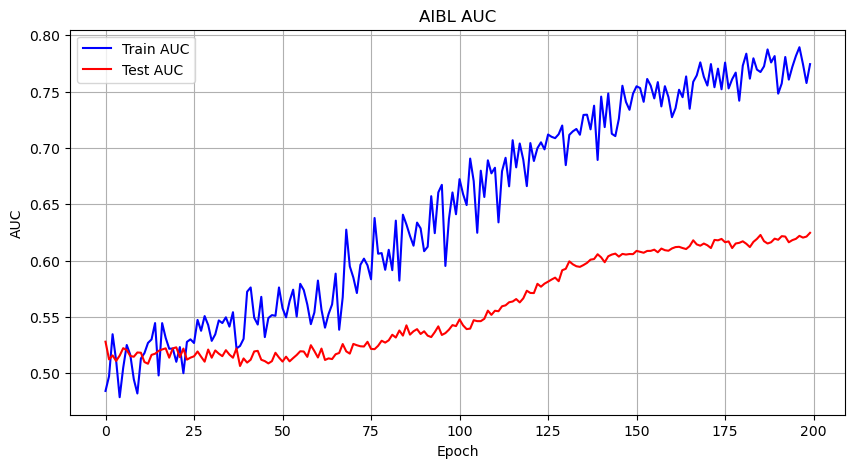

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("AIBL AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig('AIBL_CustomKG_TransE_plot.png', dpi=300)
plt.close()

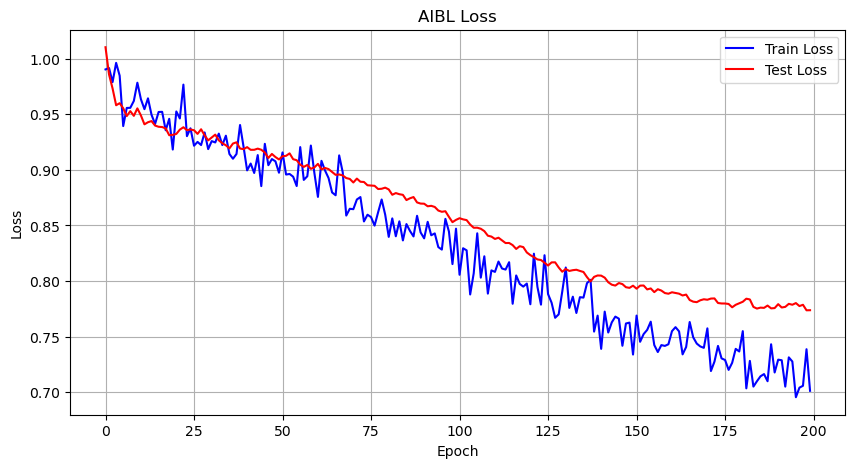

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("AIBL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig('AIBL_CustomKG_TransE_plot.png', dpi=300)
plt.close()